In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

path = r"C:\Users\user\Documents\Msc Dissertation\Telco-Customer-Churn.csv"
df_raw = pd.read_csv(path)

df_raw.shape

(7043, 21)

In [2]:
df_raw.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#checking missing values
df_raw.info()
missing_count = df_raw.isna().sum().sort_values(ascending=False)
missing_count[missing_count > 0]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Series([], dtype: int64)

In [5]:
#check for duplicates
df_raw.duplicated().sum()

0

In [6]:
#check target balance
df_raw["Churn"].value_counts(dropna=False)
df_raw["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [7]:
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum()


11

In [8]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)


In [9]:
# Summary statistics for numerical columns
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [10]:
# Summary statistics for categorical columns
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [11]:
#Check distribution extremes for key numerical features(outlier)
df[["MonthlyCharges", "TotalCharges", "tenure"]].quantile(
    [0, 0.5, 0.9, 0.95, 0.99, 1]
).T

,0.00,0.50,0.90,0.95,0.99,1.00
MonthlyCharges,18.25,70.35,102.60,107.400,114.729,118.75
TotalCharges,0.00,1394.55,5973.69,6921.025,8039.256,8684.80
tenure,0.00,29.00,69.00,72.000,72.000,72.00


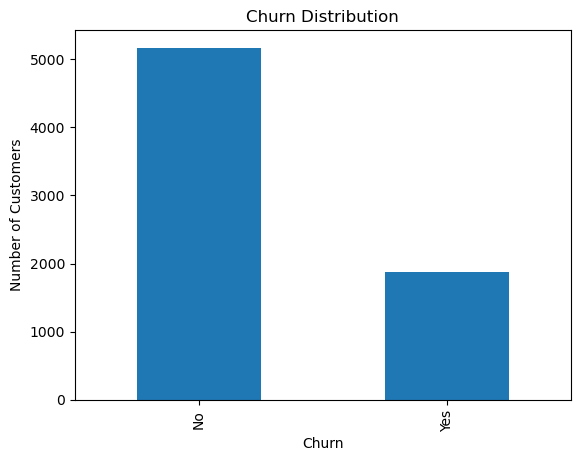

In [12]:
#identify chrun rates

df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


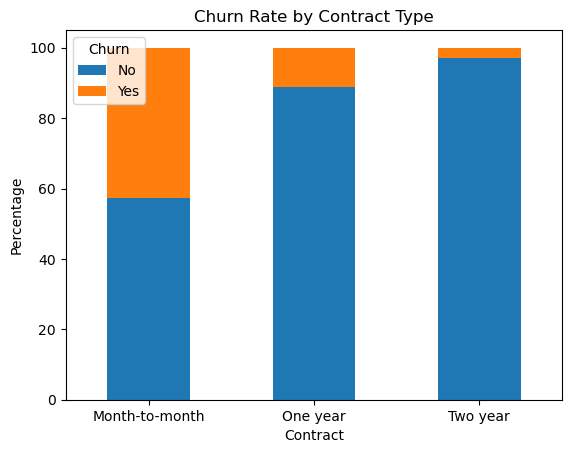

In [13]:
#Contract Type vs Churn
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

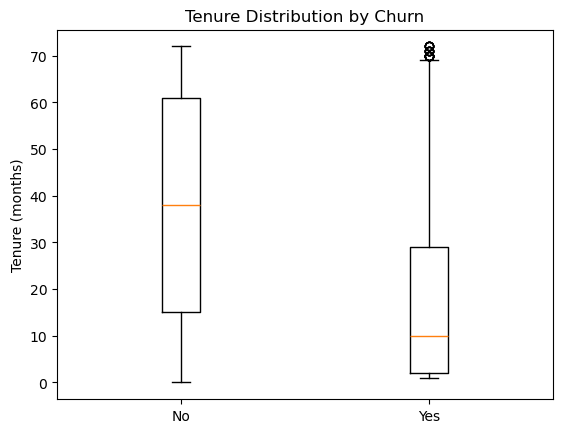

In [14]:
#tenture vs churn
churn_yes = df[df["Churn"] == "Yes"]["tenure"]
churn_no = df[df["Churn"] == "No"]["tenure"]

plt.boxplot([churn_no, churn_yes], tick_labels=["No", "Yes"])
plt.title("Tenure Distribution by Churn")
plt.ylabel("Tenure (months)")
plt.show()

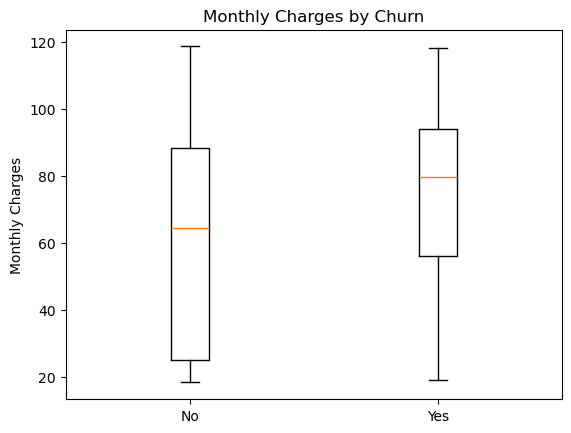

In [15]:
#monthly charges vs churn
churn_yes = df[df["Churn"] == "Yes"]["MonthlyCharges"]
churn_no = df[df["Churn"] == "No"]["MonthlyCharges"]

plt.boxplot([churn_no, churn_yes], tick_labels=["No", "Yes"])
plt.title("Monthly Charges by Churn")
plt.ylabel("Monthly Charges")
plt.show()

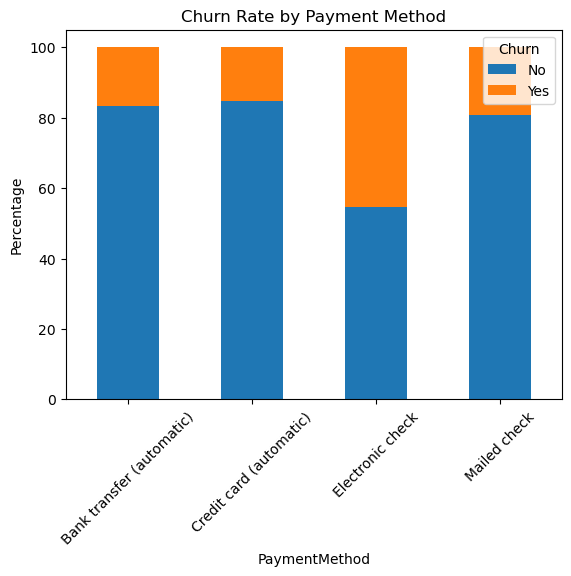

In [16]:
#payment method vs churn
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
payment_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [103]:
df_model = df.copy()

# Drop non-predictive ID column
if "customerID" in df_model.columns:
    df_model = df_model.drop(columns=["customerID"])
    
# Features and target
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"].map({"No": 0, "Yes": 1})

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True) * 100)

X shape: (7043, 19)
y distribution:
 Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [19]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain churn %:", y_train.mean() * 100)
print("Test churn %:", y_test.mean() * 100)

Train shape: (5634, 19)
Test shape: (1409, 19)

Train churn %: 26.53532126375577
Test churn %: 26.54364797728886


In [20]:
# Identify categorical and numerical columns

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Number of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numeric_cols))

print("\nCategorical columns:", categorical_cols)
print("\nNumerical columns:", numeric_cols)

Number of categorical columns: 15
Number of numerical columns: 4

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [21]:
# Preprocessing pipelines for numeric and categorical data
# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [22]:
# Compute class weights to handle imbalance
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {0: weights[0], 1: weights[1]}

print("Class weights:", class_weight_dict)

Class weights: {0: 0.6805991785455424, 1: 1.8842809364548494}


In [23]:
# Baseline model: Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight=class_weight_dict,
    random_state=42
)

clf_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", lr_model)
])

clf_lr.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [24]:
# Generate predictions on test data

y_pred_lr = clf_lr.predict(X_test) # for classification metrices

# Predicted probabilities - for ROC curve
y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


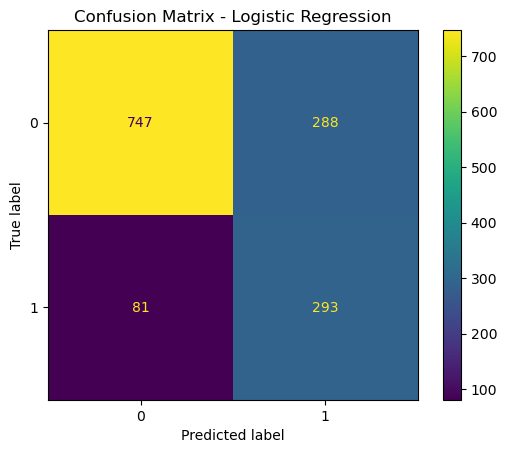

In [25]:
# Confusion Matrix for Logistic regression
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [110]:
# Logistic Regression Evaluation metrics 
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print()

print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7381121362668559

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [27]:
#ROC_AUC - Logistic regression
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Score:", roc_auc_lr)

ROC-AUC Score: 0.8416388953473353


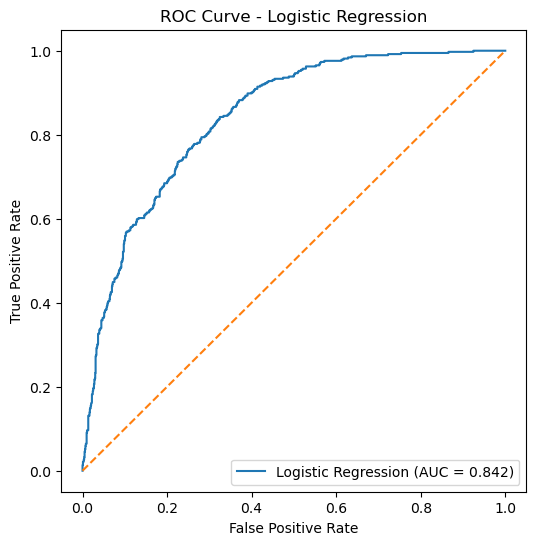

In [118]:
#roc-curve for logistic regression

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %.3f)" % roc_auc_lr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [29]:
 # Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=class_weight_dict
)

clf_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf_model)
])

clf_rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [30]:
# Generate predictions for Random Forest

y_pred_rf = clf_rf.predict(X_test)
y_prob_rf = clf_rf.predict_proba(X_test)[:,1]

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


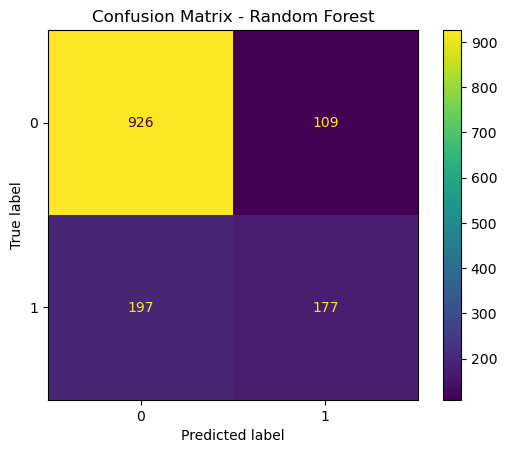

In [31]:
# Confusion Matrix for Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [112]:
# Random Forest evaluation metrics 

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report: Random Forest")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7828246983676366

Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [33]:
# Random Forest ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC Score:", roc_auc_rf)

Random Forest ROC-AUC Score: 0.823214239582526


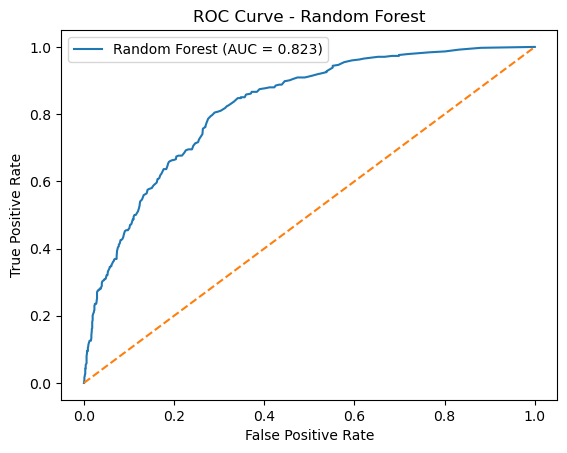

In [34]:
# ROC Curve for Random Forest

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = %0.3f)" % roc_auc_rf)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [35]:
!pip install xgboost

In [36]:
# Calculate imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 2.768561872909699


In [37]:
# XGBoost model
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

clf_xgb = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_model)
])

clf_xgb.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [38]:
# Generate predictions for XGBoost

y_pred_xgb = clf_xgb.predict(X_test)
y_prob_xgb = clf_xgb.predict_proba(X_test)[:,1]

print("XGBoost predictions generated successfully.")

XGBoost predictions generated successfully.


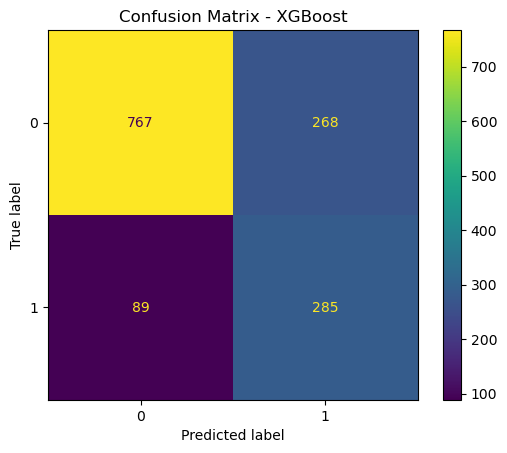

In [39]:
# Confusion Matrix for XGBoost

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot()

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [114]:
# XGBoost evaluation metrics

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report: XGBoost")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7466288147622427

Classification Report: XGBoost
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.76      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [41]:
# XGBoost ROC-AUC
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost ROC-AUC Score:", roc_auc_xgb)

XGBoost ROC-AUC Score: 0.8333126663049938


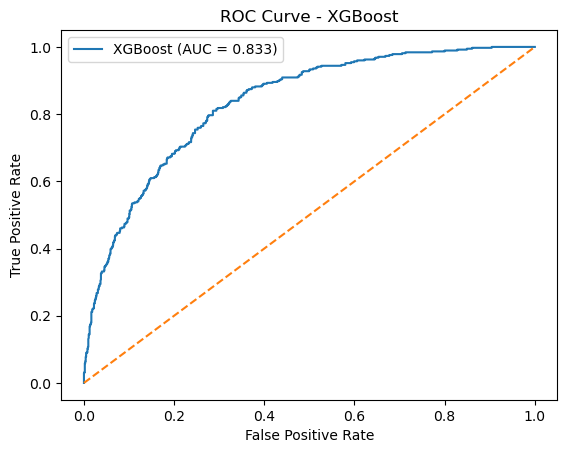

In [42]:
# ROC Curve for XGBoost

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
plt.figure()
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = %0.3f)" % roc_auc_xgb)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

In [43]:
# Model comparison table
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision (Churn)": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall (Churn)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score (Churn)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_xgb
    ]
})
model_results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision (Churn),Recall (Churn),F1 Score (Churn),ROC-AUC
0,Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841639
2,XGBoost,0.746629,0.515371,0.762032,0.614887,0.833313
1,Random Forest,0.782825,0.618881,0.473262,0.536364,0.823214


In [44]:
# Create prediction dataframe using best model (XGBoost)

predictions_df = X_test.copy()

predictions_df["Actual_Churn"] = y_test
predictions_df["Predicted_Churn"] = y_pred_xgb
predictions_df["Churn_Probability"] = y_prob_xgb

predictions_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Churn,Churn_Probability
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0,0.007792
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,1,0.951760
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0,0.226136
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,1,0.522212
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0,0.006338


In [45]:
# Customers with highest churn probability

high_risk_customers = predictions_df.sort_values(
    by="Churn_Probability",
    ascending=False
)

high_risk_customers.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Churn,Churn_Probability
2631,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.25,665.45,1,1,0.979519
4585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,1,1,0.978824
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,1,1,0.978037
6623,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,76.45,76.45,1,1,0.976393
2464,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,77.15,77.15,1,1,0.973766
6866,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,1,1,0.973219
1073,Male,0,No,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),98.05,713.00,1,1,0.971611
1731,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,69.60,69.60,1,1,0.967032
2194,Male,0,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,No,Month-to-month,Yes,Electronic check,79.50,79.50,1,1,0.966435
2900,Female,1,Yes,Yes,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,69.25,69.25,1,1,0.964314


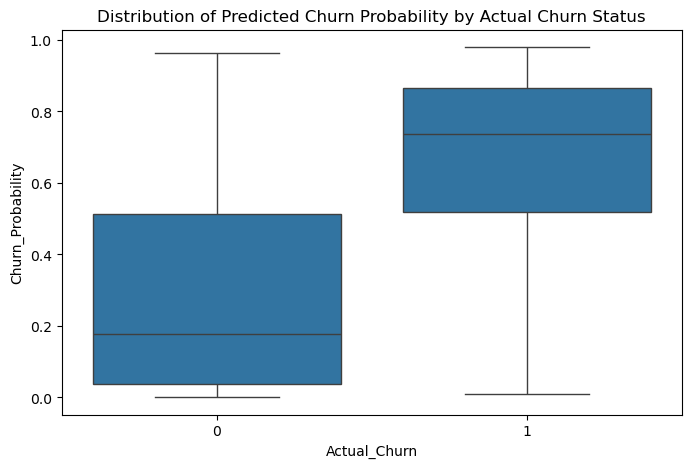

In [46]:
#predicted churn vs actual churn

plt.figure(figsize=(8,5))
sns.boxplot(x="Actual_Churn", y="Churn_Probability", data=predictions_df)

plt.title("Distribution of Predicted Churn Probability by Actual Churn Status")
plt.show()

In [47]:
# Export predictions for Power BI dashboard

predictions_df.to_csv("churn_predictions_dashboard.csv", index=False)

print("Dataset exported successfully for Power BI dashboard.")

Dataset exported successfully for Power BI dashboard.


In [48]:
!pip install shap==0.46.0

In [49]:
import shap

# Preprocess the training data
X_train_processed = clf_xgb.named_steps["preprocess"].transform(X_train)

# Create explainer using the model prediction function
explainer = shap.Explainer(clf_xgb.named_steps["model"].predict_proba, X_train_processed)

# Compute SHAP values
shap_values = explainer(X_train_processed)

print("SHAP values computed successfully.")

PermutationExplainer explainer: 5635it [13:19,  7.04it/s]                          


SHAP values computed successfully.


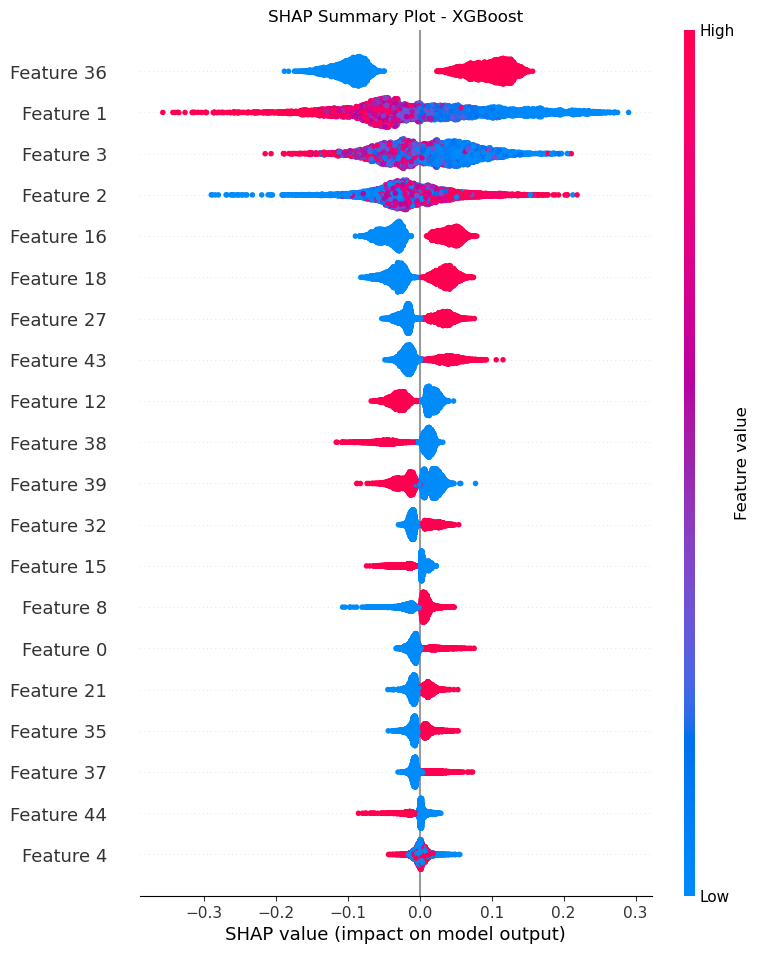

In [50]:
# SHAP summary plot

shap.summary_plot(shap_values[:, :, 1], X_train_processed, show=False)
plt.title("SHAP Summary Plot - XGBoost")
plt.show()

In [51]:
# Get feature names after preprocessing

feature_names = clf_xgb.named_steps["preprocess"].get_feature_names_out()

print("Number of features after preprocessing:", len(feature_names))
print(feature_names[:20])

Number of features after preprocessing: 45
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service']


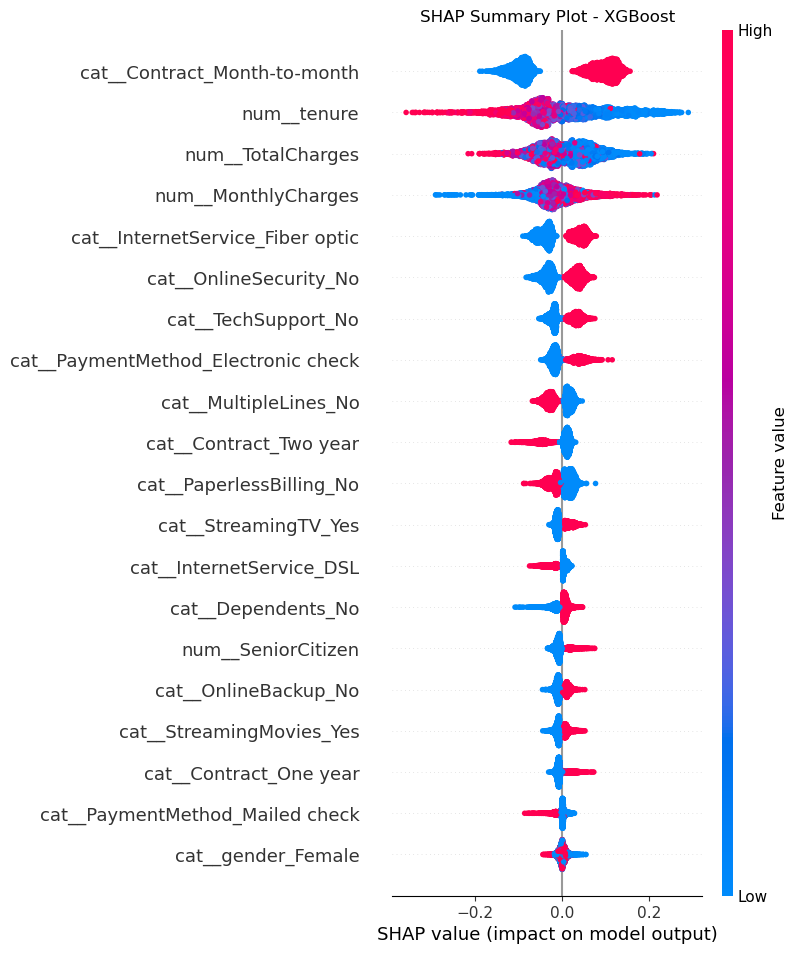

In [52]:
# SHAP summary plot with actual feature names
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_processed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot - XGBoost")
plt.show()

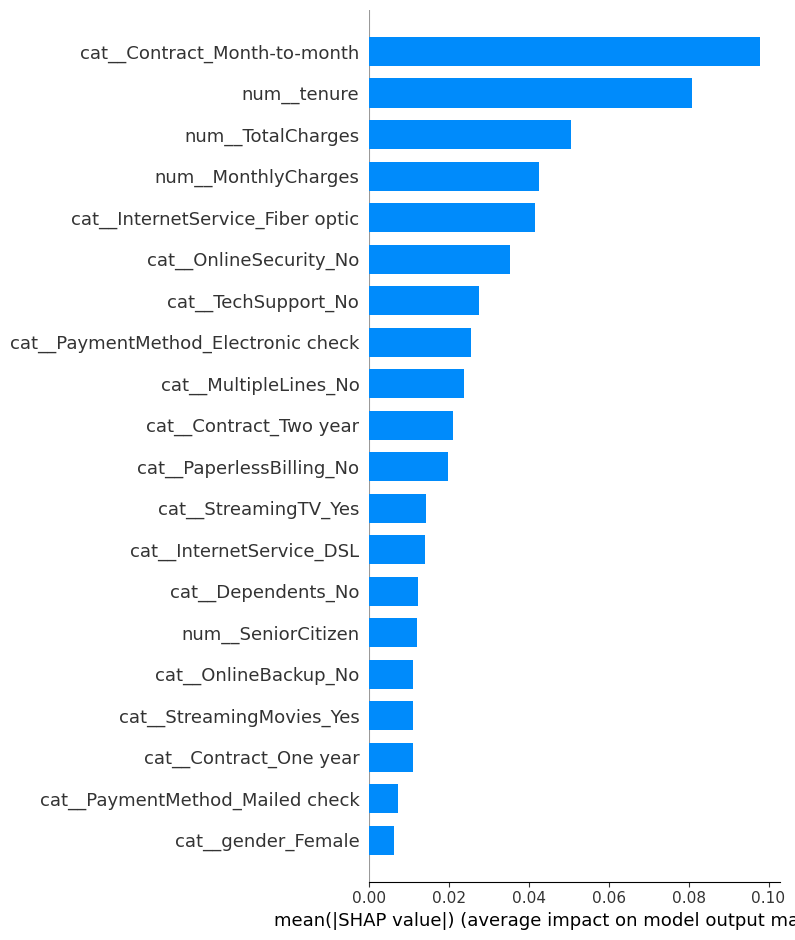

In [53]:
# SHAP Feature Importance Bar Plot

shap.summary_plot(
    shap_values[:, :, 1],
    X_train_processed,
    feature_names=feature_names,
    plot_type="bar"
)